Purpose: Plot a map of each individual genotype's collection locations for *Yucca*.<br>
Author: Anna Pardo<br>
Date initiated: May 26, 2026

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import colorcet as cc

In [2]:
print(gpd.__version__)

0.13.2


In [9]:
# load supplemental data that contains lat/long for each genotype
# also load JGI IDs
idphys = pd.read_csv("./jgi_kh_physiotype_ids.txt",sep="\t",header="infer")
idphys.head()

,Genotype,JGI_ID,geno,physiotype
0,YG1AB,IMNY,1AB,C3+CAM
1,YG45,IMNZ,45,C3+CAM
2,YG2AB,IMPA,2AB,C3+CAM
3,YG46,IMPB,46,C3+CAM
4,YG12,IMPC,12,CAM


In [7]:
supp = pd.read_csv("/home/leviathan22/Yucca_genomics/SupplementalTable1.csv",sep=",",header="infer",encoding='cp1252',
                  usecols=["Species","Genotype","Longitude","Latitude"])
supp.head()

,Species,Genotype,Longitude,Latitude
0,Yucca aloifolia,YA11,-79.064600,33.502783
1,Yucca aloifolia,YA23,-83.379064,33.927455
2,Yucca aloifolia,YA3,-75.636850,35.957517
3,Yucca aloifolia,YA32,-81.567594,31.406460
4,Yucca aloifolia,YA7,-78.925600,33.650100


In [8]:
ygsupp = supp[supp["Species"]=="Yucca gloriosa"]

In [10]:
ygsupp = ygsupp.merge(idphys)
ygsupp.head()

,Species,Genotype,Longitude,Latitude,JGI_ID,geno,physiotype
0,Yucca gloriosa,YG12,-79.064483,33.502783,IMPC,12,CAM
1,Yucca gloriosa,YG13,-80.293100,32.505917,IMPE,13,facultative CAM
2,Yucca gloriosa,YG15,-80.295700,32.503933,IMPG,15,facultative CAM
3,Yucca gloriosa,YG16,-80.430333,32.390867,IMPI,16,CAM
4,Yucca gloriosa,YG18,-81.408183,31.119067,IMPK,18,C3+CAM


In [11]:
# make a GeoDataFrame with JGI_ID
df = ygsupp[["JGI_ID","Latitude","Longitude"]]
gdf = gpd.GeoDataFrame(df,geometry=gpd.points_from_xy(df.Longitude,df.Latitude),crs="EPSG:4326")

In [15]:
gpd.datasets.available

['naturalearth_cities', 'naturalearth_lowres', 'nybb']

In [16]:
gdf.head()

,JGI_ID,Latitude,Longitude,geometry
0,IMPC,33.502783,-79.064483,POINT (-79.06448 33.50278)
1,IMPE,32.505917,-80.293100,POINT (-80.29310 32.50592)
2,IMPG,32.503933,-80.295700,POINT (-80.29570 32.50393)
3,IMPI,32.390867,-80.430333,POINT (-80.43033 32.39087)
4,IMPK,31.119067,-81.408183,POINT (-81.40818 31.11907)


In [21]:
kml_file = "./cb_2018_us_state_500k/cb_2018_us_state_500k.kml"

states = gpd.read_file(
    kml_file,
    driver="KML",
    engine="pyogrio"
)

print(states.head())

                                        Name  \
0         <at><openparen>Alabama<closeparen>   
1          <at><openparen>Alaska<closeparen>   
2  <at><openparen>American Samoa<closeparen>   
3         <at><openparen>Arizona<closeparen>   
4        <at><openparen>Arkansas<closeparen>   

                                         Description  \
0  <center><table><tr><th colspan='2' align='cent...   
1  <center><table><tr><th colspan='2' align='cent...   
2  <center><table><tr><th colspan='2' align='cent...   
3  <center><table><tr><th colspan='2' align='cent...   
4  <center><table><tr><th colspan='2' align='cent...   

                                            geometry  
0  MULTIPOLYGON Z (((-88.05338 30.50699 0.00000, ...  
1  MULTIPOLYGON Z (((179.48246 51.98283 0.00000, ...  
2  MULTIPOLYGON Z (((-168.14582 -14.54791 0.00000...  
3  POLYGON Z ((-114.81629 32.50804 0.00000, -114....  
4  POLYGON Z ((-94.61783 36.49941 0.00000, -94.61...  


In [26]:
len(gdf.index)

24

In [41]:
# set up custom colormap
colors = cc.glasbey[:24]
cmap = mcolors.ListedColormap(colors)

In [42]:
# create integer column for plotting
gdf["color_id"] = range(len(gdf))

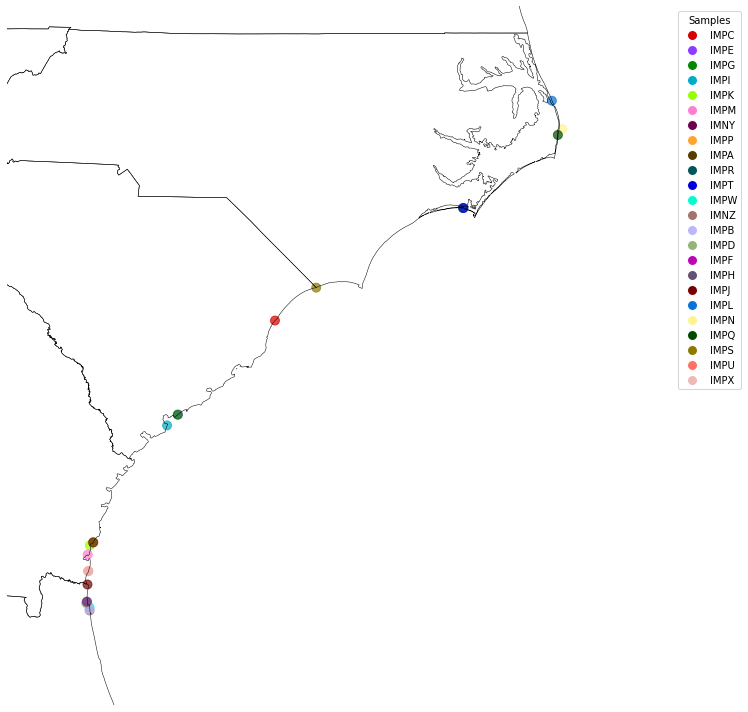

In [49]:
fig, ax = plt.subplots(figsize=(10,10))

states.boundary.plot(ax=ax, color="black", linewidth=0.5)

gdf.plot(
    ax=ax,
    column="color_id",
    cmap=cmap,
    markersize=80,
    alpha=0.7
)

# build custom legend
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=row["JGI_ID"],
        markerfacecolor=colors[i],
        markersize=10
    )
    for i, (_, row) in enumerate(gdf.iterrows())
]

ax.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title="Samples"
)

xmin, ymin, xmax, ymax = gdf.total_bounds

# padding in degrees
xpad = 1
ypad = 1

ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

ax.set_axis_off()

plt.tight_layout()
plt.savefig("./map_by_jgi_ids.png",dpi=300,bbox_inches="tight")